# **ΟΜΑΔΑ ΕΡΓΑΣΙΑΣ 3 - Ερώτηση 3**
*   Δημούδης Γεώργιος 5212
*   Στρούγγης Γεώργιος 5357

In [ ]:
#Cells are expected to be run in order as seen. Thank you.
!pip install gensim

import gensim.downloader as api
word2vec = api.load("word2vec-google-news-300")

import nltk
nltk.download('stopwords')

import pandas as pd
from nltk.corpus import stopwords
import re
import ast
import sklearn as sk
import numpy as np
import random
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 68.5 MB/s eta 0:00:00
[==================================================] 100.0% 1662.8/1662.8MB downloaded


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
#creates the dataframe
df = pd.read_csv("movies_metadata.csv", usecols=["id","genres","overview"], on_bad_lines="skip")

#method for finding if a movie has exactly one of the wanted genres, if it has none or multiple then it is filtered out
accepted_genres = ["War","Music","Animation"]
def belongs_to_genres(genre_list):
  num_of_genres = 0
  for i in genre_list:
    if i in accepted_genres:
      num_of_genres += 1
  if num_of_genres != 1:
    return False
  else:
    return True

#processing the genres to extract their names and keep them in a list
for index, row in df.iterrows():
  temp = []
  text = row['genres']
  text = ast.literal_eval(text)
  if len(text) != 0:
    for i in range(len(text)):
      temp.append(text[i]["name"])
    if (len(temp) != 0) & (belongs_to_genres(temp)):
      for j in temp:
        if j in accepted_genres:
          df.at[index, 'genres'] = j
    else:
      df.at[index, 'genres'] = None
  else:
    df.at[index, 'genres'] = None

df = df.dropna()

#loads stopwords
stop_words = set(stopwords.words('english'))

#processes the overview so we can keep a list of keywords, prints the current state of the dataframe
for index, row in df.iterrows():
  temp = []
  text = row['overview']
  text = re.sub(r'[^\w\s]', '', text)
  text = text.lower().split(" ")
  if len(text) != 0:
    for i in text:
      if i not in stop_words:
        temp.append(i)
    if len(temp) != 0:
      df.at[index, 'overview'] = temp
    else:
      df.at[index, 'overview'] = None
  else:
    df.at[index, 'overview'] = None

df = df.dropna()
print(df)

          genres      id                                           overview
0      Animation     862  [led, woody, andys, toys, live, happily, room,...
12     Animation   21032  [outcast, halfwolf, risks, life, prevent, dead...
40           War   31174  [shakespeares, play, transplanted, 1930s, sett...
47     Animation   10530  [history, comes, gloriously, life, disneys, ep...
61         Music    2054  [1965, passionate, musician, glenn, holland, t...
...          ...     ...                                                ...
45386  Animation  175457            [abstract, animation, walter, ruttmann]
45388  Animation  184402            [abstract, animation, walter, ruttmann]
45433      Music    5589                                  [overview, found]
45437  Animation  455661  [closeted, boy, runs, risk, outed, heart, pops...
45449  Animation   14885  [halloween, 100, acre, wood, roos, best, new, ...

[4630 rows x 3 columns]


Accuracy = [0.73110151 0.73650108 0.70086393 0.71598272 0.69330454]
Precision = [0.73164344 0.73663613 0.71030326 0.72257018 0.70633897]
Recall = [0.73682358 0.74135181 0.70614093 0.72508334 0.69590223]


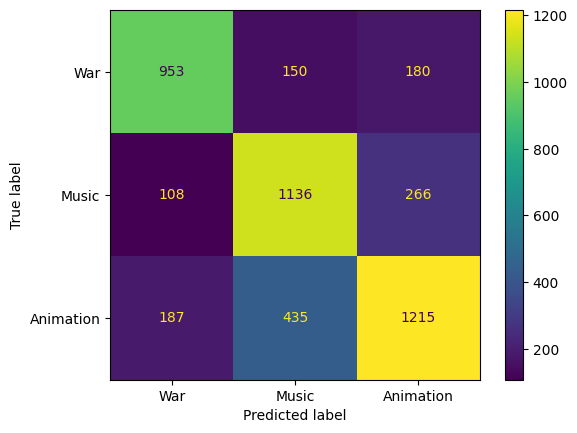

In [ ]:
#we are asked to test two methods of feature extraction
#first we'll do tf-idf for decision tree

#keeps list of overviews
overviews = df["overview"].tolist()

#fuses all keywords for each movie into a sentence as this is the acceptable format for tfidf
#also keeps their genres as the 'correct answers' which will be used for training
x_train = [' '.join(i) for i in overviews]
y_train = df["genres"].tolist()

#defines a pipeline which will first run the tfidf vectorizer and then the decision tree for each iteration of the 5 fold cross validation
#we did this because it was the simplest way to implement what the exercise asks us for
decision_tree_pipeline = sk.pipeline.Pipeline([
    ('tfidf', sk.feature_extraction.text.TfidfVectorizer(max_features=5000)),
    ('decision_tree', sk.tree.DecisionTreeClassifier())
])

#does 5 fold cross validation for decision tree and TF-IDF
cross_val_scores = sk.model_selection.cross_validate(decision_tree_pipeline, x_train, y_train, scoring = ['accuracy','precision_macro', 'recall_macro'], cv=5)
print(f"Accuracy = {cross_val_scores['test_accuracy']}")
print(f"Precision = {cross_val_scores['test_precision_macro']}")
print(f"Recall = {cross_val_scores['test_recall_macro']}")

#we keep a list of the cross validation scores for a final comparison in the end
cross_val_list = []
cross_val_list.append(cross_val_scores)

#computes confusion matrix for decision tree and TF-IDF
y_preds = sk.model_selection.cross_val_predict(decision_tree_pipeline, x_train, y_train, cv=5)
confusion_matrix = sk.metrics.confusion_matrix(y_train, y_preds, labels=accepted_genres)
disp = sk.metrics.ConfusionMatrixDisplay(confusion_matrix=confusion_matrix, display_labels=accepted_genres)
disp.plot()
plt.show()

#we print the accuracy, precision, recall scores as well as the confusion matrix for the 5 fold training we did
#accuracy is how correct our model was overall, prediction is how good it was at predicting specific categories and recall how many times it managed to detect a specific category
#generally, scores above 0.7 are considered good for all three, though not ideal and on the fifth fold we get scores under 0.7, meaning there is room for improvement

#as for the confusion matrix, it shows us how many movies of each genre were assigned to different genres
#warm colours like yellow and green are present for genres that were accurately assigned, indicating our model did a relatively good job
#even so, there is a considerable number of inaccurate predictions, indicating there is room for improvement

#overall tfidf + decision tree is a solid method to begin with, but not ideal

Accuracy = [0.65982721 0.65226782 0.65334773 0.66522678 0.6663067 ]
Precision = [0.65888353 0.65161365 0.65296386 0.66420633 0.67391079]
Recall = [0.65921446 0.65564826 0.64923877 0.66662264 0.66656903]


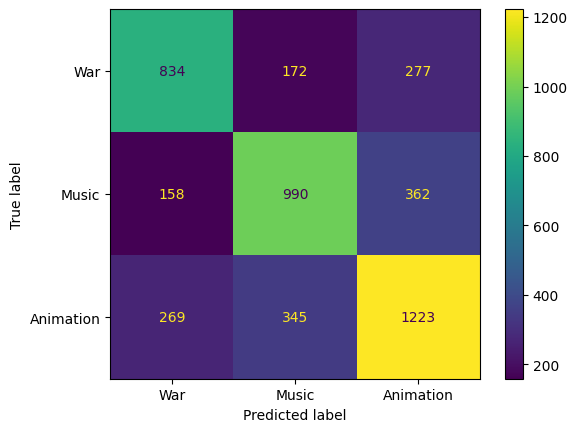

In [ ]:
#now we'll do word2vec for decision tree

#computes the vector mean for each movie
#we have no need for the pipeline here because we run the train data through word2vec only once
#the exercise only told us to do it for each iteration for tfidf
vector_means = []
for summary in overviews:
  vectors = [word2vec[word] for word in summary if word in word2vec]
  if len(vectors) != 0:
    vector_means.append(np.mean(vectors, axis=0))
  else:
    vector_means.append(np.zeros(300))

#does 5 fold cross validation for decision tree and word2vec
cross_val_scores = sk.model_selection.cross_validate(sk.tree.DecisionTreeClassifier(), vector_means, y_train, scoring = ['accuracy','precision_macro', 'recall_macro'], cv=5)
print(f"Accuracy = {cross_val_scores['test_accuracy']}")
print(f"Precision = {cross_val_scores['test_precision_macro']}")
print(f"Recall = {cross_val_scores['test_recall_macro']}")
cross_val_list.append(cross_val_scores)

#computes confusion matrix for decision tree and word2vec
y_preds = sk.model_selection.cross_val_predict(sk.tree.DecisionTreeClassifier(), vector_means, y_train, cv=5)
confusion_matrix = sk.metrics.confusion_matrix(y_train, y_preds, labels=accepted_genres)
disp = sk.metrics.ConfusionMatrixDisplay(confusion_matrix=confusion_matrix, display_labels=accepted_genres)
disp.plot()
plt.show()

#accuracy, precision and recall scores for word2vec + decision tree are consistently worse than tfidf + decision tree, not to a massive degree but enough to be considered inferior
#likewise, the confusion matrix has a higher number of inaccurate predictions
#it is noteworthy however that the number of correctly predicted movies of the Animation genre remains almost the same, espcially compared to War and Music movies that lost over a hundred movies each
#in conclusion, word2vec + decision tree can be inferred to be an inferior method overall

N = 3
Accuracy = [0.32937365 0.69006479 0.33261339 0.32937365 0.67926566]
Precision = [0.77573131 0.68934476 0.72834319 0.69227289 0.72422624]
Recall = [0.33644701 0.68814223 0.33897619 0.33625139 0.6738251 ]
N = 5
Accuracy = [0.63066955 0.72678186 0.6425486  0.6511879  0.73542117]
Precision = [0.72420898 0.73671547 0.72319572 0.744871   0.77380717]
Recall = [0.63177286 0.72487688 0.6443125  0.65780976 0.72649519]
N = 10
Accuracy = [0.76349892 0.77645788 0.76133909 0.75809935 0.80885529]
Precision = [0.77898563 0.77772853 0.78528487 0.77747125 0.82370567]
Recall = [0.77112464 0.77783789 0.76249078 0.7677365  0.80400723]
N = 15
Accuracy = [0.79481641 0.80453564 0.79265659 0.79913607 0.82289417]
Precision = [0.80039478 0.80328234 0.80197318 0.8056694  0.83356835]
Recall = [0.79957327 0.80178415 0.79328444 0.80379892 0.81891802]
N = 20
Accuracy = [0.81425486 0.81857451 0.82289417 0.80885529 0.83477322]
Precision = [0.81769844 0.81896024 0.82939707 0.81354934 0.84555491]
Recall = [0.817661

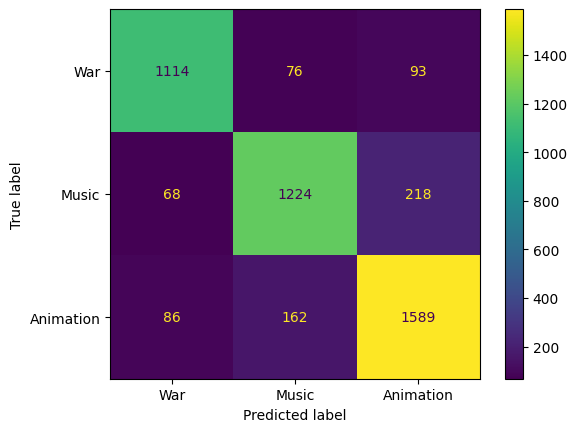

In [ ]:
#defines a pipeline which will first run the tfidf vectorizer and then the kNN for each iteration of the 5 fold cross validation
#we run multiple tests for different numbers of neighbours to find the optimal one
n_values = [3,5,10,15,20,50,100]
for n in n_values:
  knn_pipeline = sk.pipeline.Pipeline([
      ('tfidf', sk.feature_extraction.text.TfidfVectorizer(max_features=5000)),
      ('K_Neighbours', sk.neighbors.KNeighborsClassifier(n_neighbors=n))
  ])

  cross_val_scores = sk.model_selection.cross_validate(knn_pipeline, x_train, y_train, scoring = ['accuracy','precision_macro', 'recall_macro'], cv=5)
  print(f"N = {n}")
  print(f"Accuracy = {cross_val_scores['test_accuracy']}")
  print(f"Precision = {cross_val_scores['test_precision_macro']}")
  print(f"Recall = {cross_val_scores['test_recall_macro']}")

#from our results we can assess that larger numbers of neighbours directly correlate to better results
#with only 10 neighbours we can match and slightly surpass the performance of the Decision Tree Classifier with values around 0.75-0.8 without experiencing a drop in the last round, instead it actually seems to improve
#our values continue to improve as we increase the number of neighbours, though they seem to plateau after n=20 at around 0.85
#we'll consider n=50 our ideal number of neighbours for the time being and use it for the confusion matrix

knn_pipeline = sk.pipeline.Pipeline([
      ('tfidf', sk.feature_extraction.text.TfidfVectorizer(max_features=5000)),
      ('K_Neighbours', sk.neighbors.KNeighborsClassifier(n_neighbors=50))
  ])
cross_val_scores = sk.model_selection.cross_validate(knn_pipeline, x_train, y_train, scoring = ['accuracy','precision_macro', 'recall_macro'], cv=5)
cross_val_list.append(cross_val_scores)

#computes confusion matrix for kNN and TF-IDF
y_preds = sk.model_selection.cross_val_predict(knn_pipeline, x_train, y_train, cv=5)
confusion_matrix = sk.metrics.confusion_matrix(y_train, y_preds, labels=accepted_genres)
disp = sk.metrics.ConfusionMatrixDisplay(confusion_matrix=confusion_matrix, display_labels=accepted_genres)
disp.plot()
plt.show()

#in the confusion matrix we continue to see better results that the Decision Tree with the correct guesses being in the thousands for each of the three categories
#although there is still a notable number of wrong guesses such as Music being assigned as Animation and vice versa
#but besides them the number of wrong guesses for the other categories has decreased to the double digits
#it's also quite likely that because animated movies are commonly also musicals, that causes the mix up

#for now, tfidf + kNN seems to be our best method

Accuracy = [0.85961123 0.86393089 0.84449244 0.84341253 0.82289417]
Precision = [0.8607493  0.86411009 0.85020616 0.84375888 0.82803666]
Recall = [0.86243844 0.86824214 0.84875699 0.84727116 0.82669972]


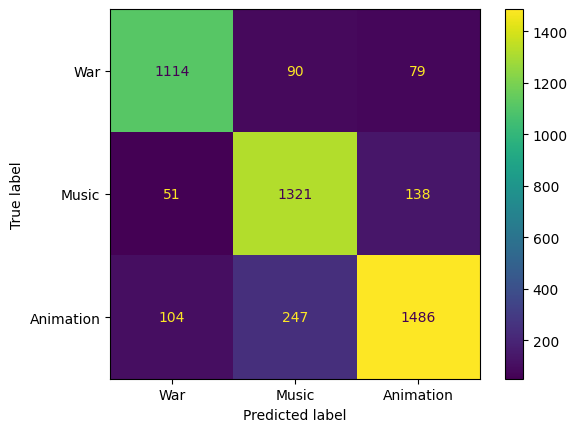

In [ ]:
#now we'll do word2vec for kNN

#does 5 fold cross validation for kNN and word2vec
#we'll use n=50 since it was out ideal value for the tfidf version
cross_val_scores = sk.model_selection.cross_validate(sk.neighbors.KNeighborsClassifier(n_neighbors=50), vector_means, y_train, scoring = ['accuracy','precision_macro', 'recall_macro'], cv=5)
print(f"Accuracy = {cross_val_scores['test_accuracy']}")
print(f"Precision = {cross_val_scores['test_precision_macro']}")
print(f"Recall = {cross_val_scores['test_recall_macro']}")
cross_val_list.append(cross_val_scores)

#computes confusion matrix for kNN and word2vec
y_preds = sk.model_selection.cross_val_predict(sk.neighbors.KNeighborsClassifier(n_neighbors=50), vector_means, y_train, cv=5)
confusion_matrix = sk.metrics.confusion_matrix(y_train, y_preds, labels=accepted_genres)
disp = sk.metrics.ConfusionMatrixDisplay(confusion_matrix=confusion_matrix, display_labels=accepted_genres)
disp.plot()
plt.show()

#the results are generally comparable to the tfidf version and unlike with the Decision Tree, using word2vec here did not provide worse results
#a few things are notable, for once, the accuracy, precision and recall scores while similar, seem to marginally decrease across the five rounds
#also, while it guessed less Animation movies correctly, it guessed more Music ones right
#the results are different than the tfidf version in terms of specific numbers, but broadly they are still comparable and quite otpimal
#in conclusion, this remains a good classifier to use for our task

Accuracy = [0.85961123 0.86933045 0.85097192 0.86177106 0.85097192]
Precision = [0.86827389 0.87696943 0.86395698 0.87232997 0.86535235]
Recall = [0.85630181 0.86524431 0.84581618 0.85646718 0.84466994]


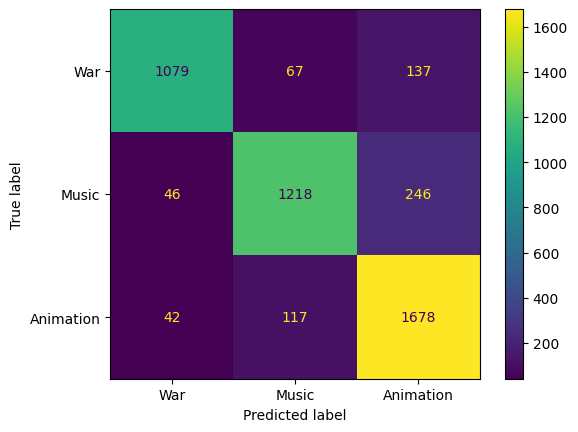

In [ ]:
#defines a pipeline which will first run the tfidf vectorizer and then logistic regression for each iteration of the 5 fold cross validation
logistic_pipeline = sk.pipeline.Pipeline([
    ('tfidf', sk.feature_extraction.text.TfidfVectorizer(max_features=5000)),
    ('logistic_regression', sk.linear_model.LogisticRegression())
])

#does 5 fold cross validation for logistic regression and TF-IDF
cross_val_scores = sk.model_selection.cross_validate(logistic_pipeline, x_train, y_train, scoring = ['accuracy','precision_macro', 'recall_macro'], cv=5)
print(f"Accuracy = {cross_val_scores['test_accuracy']}")
print(f"Precision = {cross_val_scores['test_precision_macro']}")
print(f"Recall = {cross_val_scores['test_recall_macro']}")
cross_val_list.append(cross_val_scores)

#computes confusion matrix for logistic regression and TF-IDF
y_preds = sk.model_selection.cross_val_predict(logistic_pipeline, x_train, y_train, cv=5)
confusion_matrix = sk.metrics.confusion_matrix(y_train, y_preds, labels=accepted_genres)
disp = sk.metrics.ConfusionMatrixDisplay(confusion_matrix=confusion_matrix, display_labels=accepted_genres)
disp.plot()
plt.show()

#using logistic regression, we can assess that its scores are comparable to those of kNN, making it another very good choice
#while in the confusion matrix we see marginally worse results for the number of movies correctly predicted as War or Music-
#as well as a higher number of War movies mislabeled as Animation, it has the best amount of correctly predicted animation movies

Accuracy = [0.89524838 0.8887689  0.87796976 0.86069114 0.86177106]
Precision = [0.89541667 0.88993981 0.880316   0.8599964  0.86870185]
Recall = [0.8951045  0.88828365 0.87905023 0.86218326 0.86055686]


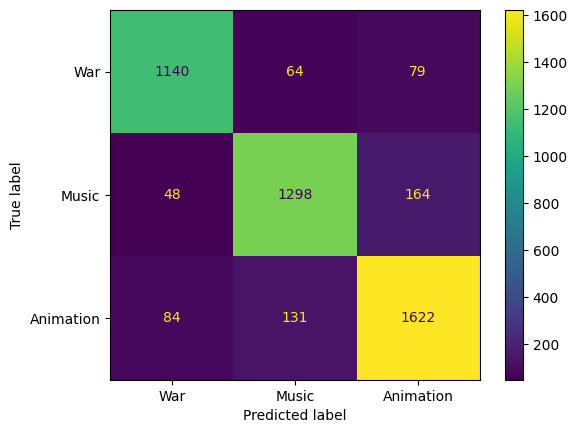

In [ ]:
#now we'll do word2vec for Logistic Regression

#does 5 fold cross validation for Logistic Regression and word2vec
cross_val_scores = sk.model_selection.cross_validate(sk.linear_model.LogisticRegression(), vector_means, y_train, scoring = ['accuracy','precision_macro', 'recall_macro'], cv=5)
print(f"Accuracy = {cross_val_scores['test_accuracy']}")
print(f"Precision = {cross_val_scores['test_precision_macro']}")
print(f"Recall = {cross_val_scores['test_recall_macro']}")
cross_val_list.append(cross_val_scores)

#computes confusion matrix for Logistic Regression and word2vec
y_preds = sk.model_selection.cross_val_predict(sk.linear_model.LogisticRegression(), vector_means, y_train, cv=5)
confusion_matrix = sk.metrics.confusion_matrix(y_train, y_preds, labels=accepted_genres)
disp = sk.metrics.ConfusionMatrixDisplay(confusion_matrix=confusion_matrix, display_labels=accepted_genres)
disp.plot()
plt.show()

#in a surprising turn of events, word2vec + Logistic Regression boasts the highest scores and some of the highest correct guesses we've seen so far
#there is a noticeable pattern of the scores getting marginally worse with each of the five folds, but they are still within an acceptable range
#still some misidenfitied movies, but overall very good performance

Accuracy = [0.85529158 0.86609071 0.85205184 0.86177106 0.84989201]
Precision = [0.87059764 0.87667029 0.86940438 0.87668995 0.86795963]
Recall = [0.84950908 0.86054549 0.84478291 0.85588072 0.84317743]


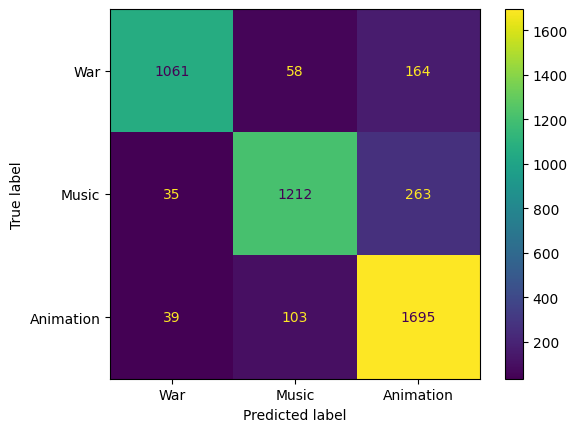

In [ ]:
#defines a pipeline which will first run the tfidf vectorizer and then SVM for each iteration of the 5 fold cross validation
svm_pipeline = sk.pipeline.Pipeline([
    ('tfidf', sk.feature_extraction.text.TfidfVectorizer(max_features=5000)),
    ('SVM', sk.svm.SVC())
])

#does 5 fold cross validation for SVM and TF-IDF
cross_val_scores = sk.model_selection.cross_validate(svm_pipeline, x_train, y_train, scoring = ['accuracy','precision_macro', 'recall_macro'], cv=5)
print(f"Accuracy = {cross_val_scores['test_accuracy']}")
print(f"Precision = {cross_val_scores['test_precision_macro']}")
print(f"Recall = {cross_val_scores['test_recall_macro']}")
cross_val_list.append(cross_val_scores)

#computes confusion matrix for SVM and TF-IDF
y_preds = sk.model_selection.cross_val_predict(svm_pipeline, x_train, y_train, cv=5)
confusion_matrix = sk.metrics.confusion_matrix(y_train, y_preds, labels=accepted_genres)
disp = sk.metrics.ConfusionMatrixDisplay(confusion_matrix=confusion_matrix, display_labels=accepted_genres)
disp.plot()
plt.show()

#SVM + tfidf provides similar results to the prior two classifiers, making it another good choice
#we tried out different kernals for it such as rbf, linear and sigmoid, but there was little to no meaningful variation between them so we just used default settings
#it's another acceptable classifier, however it should be noted that it is much slower, taking upwards of a minute (technically 0.5 minutes because we have to run it twice), so others might be more optimal especially for more data

Accuracy = [0.89632829 0.89092873 0.88660907 0.8812095  0.86933045]
Precision = [0.89615263 0.89334841 0.89221579 0.88207895 0.88048928]
Recall = [0.89759544 0.89187872 0.88456586 0.88080204 0.86535748]


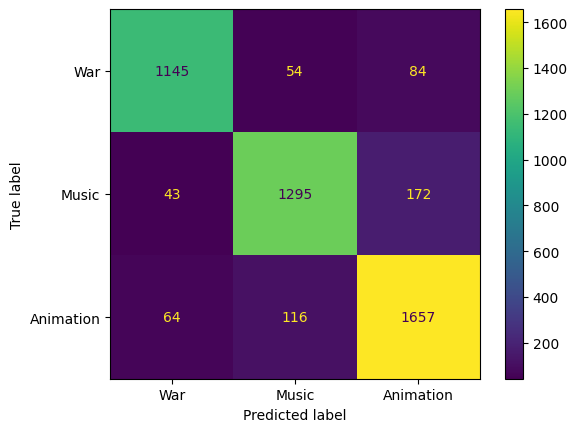

In [ ]:
#now we'll do word2vec for SVM

#does 5 fold cross validation for SVM and word2vec
cross_val_scores = sk.model_selection.cross_validate(sk.svm.SVC(), vector_means, y_train, scoring = ['accuracy','precision_macro', 'recall_macro'], cv=5)
print(f"Accuracy = {cross_val_scores['test_accuracy']}")
print(f"Precision = {cross_val_scores['test_precision_macro']}")
print(f"Recall = {cross_val_scores['test_recall_macro']}")
cross_val_list.append(cross_val_scores)

#computes confusion matrix for SVM and word2vec
y_preds = sk.model_selection.cross_val_predict(sk.svm.SVC(), vector_means, y_train, cv=5)
confusion_matrix = sk.metrics.confusion_matrix(y_train, y_preds, labels=accepted_genres)
disp = sk.metrics.ConfusionMatrixDisplay(confusion_matrix=confusion_matrix, display_labels=accepted_genres)
disp.plot()
plt.show()

#word2vec + SVM, much like word2vec + Logistic Regression provides very good scores and numbers of correct guesses
#plus, it's faster than tfidf + SVM, making it a preferable application of the classifier and one of the best

Accuracy = [0.83477322 0.83909287 0.84017279 0.84449244 0.8412527 ]
Precision = [0.83619031 0.84111908 0.84100222 0.84716107 0.85103394]
Recall = [0.83764712 0.84067456 0.84276919 0.84504495 0.84116057]


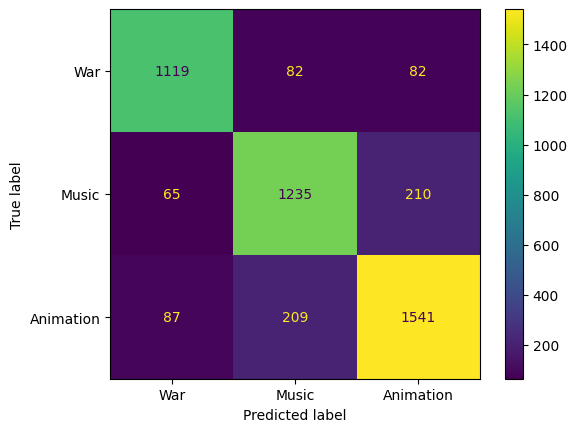

In [ ]:
#defines a pipeline which will first run the tfidf vectorizer and then MLP for each iteration of the 5 fold cross validation
mlp_pipeline = sk.pipeline.Pipeline([
    ('tfidf', sk.feature_extraction.text.TfidfVectorizer(max_features=5000)),
    ('MLP', sk.neural_network.MLPClassifier())
])

#does 5 fold cross validation for MLP and TF-IDF
cross_val_scores = sk.model_selection.cross_validate(mlp_pipeline, x_train, y_train, scoring = ['accuracy','precision_macro', 'recall_macro'], cv=5)
print(f"Accuracy = {cross_val_scores['test_accuracy']}")
print(f"Precision = {cross_val_scores['test_precision_macro']}")
print(f"Recall = {cross_val_scores['test_recall_macro']}")
cross_val_list.append(cross_val_scores)

#computes confusion matrix for MLP and TF-IDF
y_preds = sk.model_selection.cross_val_predict(mlp_pipeline, x_train, y_train, cv=5)
confusion_matrix = sk.metrics.confusion_matrix(y_train, y_preds, labels=accepted_genres)
disp = sk.metrics.ConfusionMatrixDisplay(confusion_matrix=confusion_matrix, display_labels=accepted_genres)
disp.plot()
plt.show()

#tfidf + MLP provides marginally worse but still very good scores
#we tried various different parameters such as different max_iter, hidden_layer_sizes and solvers, but the results remained generally the same so we just used the default values
#the most major thing to comment on is how long it takes to run, going up to almost five minutes (technically 2.5 since we have to run it twice), thus making other classifiers more optimal

Accuracy = [0.87580994 0.85853132 0.85313175 0.84773218 0.85205184]
Precision = [0.8754249  0.85750697 0.85266857 0.84647682 0.85603624]
Recall = [0.87939589 0.85836573 0.85542998 0.85088865 0.85121177]


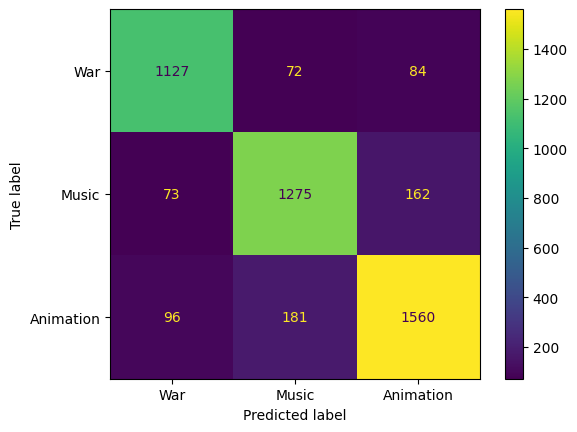

In [ ]:
#now we'll do word2vec for MLP

#does 5 fold cross validation for MLP and word2vec
cross_val_scores = sk.model_selection.cross_validate(sk.neural_network.MLPClassifier(max_iter=500), vector_means, y_train, scoring = ['accuracy','precision_macro', 'recall_macro'], cv=5)
print(f"Accuracy = {cross_val_scores['test_accuracy']}")
print(f"Precision = {cross_val_scores['test_precision_macro']}")
print(f"Recall = {cross_val_scores['test_recall_macro']}")
cross_val_list.append(cross_val_scores)

#computes confusion matrix for MLP and word2vec
y_preds = sk.model_selection.cross_val_predict(sk.neural_network.MLPClassifier(max_iter=500), vector_means, y_train, cv=5)
confusion_matrix = sk.metrics.confusion_matrix(y_train, y_preds, labels=accepted_genres)
disp = sk.metrics.ConfusionMatrixDisplay(confusion_matrix=confusion_matrix, display_labels=accepted_genres)
disp.plot()
plt.show()

#word2vec + MLP provides better results that the tfidf version but is similarly slow, making word2vec + SVM or Logistic Regression remain better
#one noteworthy thing about it is that we had to set the number of max_iter as _ because the default 200 was not enough for it as we got a warning that the model was still in the process of learning when it hit the limit

In [ ]:
classifier_scores = {
    'Classifier': ['Decision Tree', 'kNN', 'Logistic Regression', 'SVM', 'MLP'],
    'TF-IDF Accuracy': [np.mean(cross_val_list[i]['test_accuracy']) for i in [0,2,4,6,8]],
    'TF-IDF Precision': [np.mean(cross_val_list[i]['test_precision_macro']) for i in [0,2,4,6,8]],
    'TF-IDF Recall': [np.mean(cross_val_list[i]['test_recall_macro']) for i in [0,2,4,6,8]],
    'Word2Vec Accuracy': [np.mean(cross_val_list[i]['test_accuracy']) for i in [1,3,5,7,9]],
    'Word2Vec Precision': [np.mean(cross_val_list[i]['test_precision_macro']) for i in [1,3,5,7,9]],
    'Word2Vec Recall': [np.mean(cross_val_list[i]['test_recall_macro']) for i in [1,3,5,7,9]]
}
scores_table = pd.DataFrame(classifier_scores)
print(scores_table)

#in conclusion, the most optimal classifiers seem to Logistic Regression and SVM when paired up with word2vec feature extraction, providing high amounts of correct guesses without taking too long

Final Comparison Table:
            Classifier  TF-IDF Accuracy  TF-IDF Precision  TF-IDF Recall  \
0        Decision Tree         0.715551          0.721498       0.721060   
1                  kNN         0.848164          0.851118       0.847963   
2  Logistic Regression         0.858531          0.869377       0.853700   
3                  SVM         0.857019          0.872264       0.850779   
4                  MLP         0.839957          0.843301       0.841459   

   Word2Vec Accuracy  Word2Vec Precision  Word2Vec Recall  
0           0.659395            0.660316         0.659459  
1           0.846868            0.849372         0.850682  
2           0.876890            0.878874         0.877036  
3           0.884881            0.888857         0.884040  
4           0.861555            0.862285         0.862785  
